Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12,6)


Load Dataset

In [2]:
df = pd.read_csv("MMDU_Student_Performance.csv")

df.head()

,student_id,roll_number,registration_number,university_id,college_id,department_id,program_name,specialization,gender,date_of_birth,...,faculty_rating_avg,student_teacher_ratio,class_size,teaching_method,course_feedback_score,library_usage_frequency,lab_access_hours,mentorship_sessions_attended,remedial_classes_attended,placement_training_participation
0,1,BCA0001,MMDU2026REG0001,MMDU,MMICTBM,CS,BCA,AI,Male,2003-06-08,...,4.81,26,38,Traditional,4.43,11,22,1,3,Yes
1,2,BCA0002,MMDU2026REG0002,MMDU,MMICTBM,CS,BCA,Cyber Security,Male,2003-03-25,...,3.62,25,59,Traditional,4.59,19,31,4,4,Yes
2,3,BCA0003,MMDU2026REG0003,MMDU,MMICTBM,CS,BCA,Data Science,Female,2004-07-31,...,4.83,31,53,Blended,3.80,13,40,0,0,No
3,4,BCA0004,MMDU2026REG0004,MMDU,MMICTBM,CS,BCA,Cloud,Male,2002-10-11,...,3.83,23,33,Traditional,4.91,28,15,1,1,No
4,5,BCA0005,MMDU2026REG0005,MMDU,MMICTBM,CS,BCA,Data Science,Male,2002-01-11,...,4.45,23,40,Blended,4.31,24,33,7,0,No


Check Unique Semesters

In [3]:
df['semester'].unique()

array(['VI'], dtype=object)

Convert Semester to Numeric

In [4]:
# If Roman format exists, convert manually
roman_map = {
    'I':1,'II':2,'III':3,'IV':4,
    'V':5,'VI':6,'VII':7,'VIII':8
}

df['semester'] = df['semester'].replace(roman_map)
df['semester'] = pd.to_numeric(df['semester'], errors='coerce')


C:\Users\PRATI\AppData\Local\Temp\ipykernel_21940\2775150592.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['semester'] = df['semester'].replace(roman_map)


Time-Series Aggregation

In [5]:
semester_data = df.groupby('semester').agg({
    'cgpa': 'mean',
    'sgpa': 'mean',
    'percentage': 'mean',
    'attendance_percentage': 'mean',
    'stress_level': 'mean'
}).reset_index()

semester_data = semester_data.sort_values('semester')

semester_data


,semester,cgpa,sgpa,percentage,attendance_percentage,stress_level
0,6,7.515517,7.200425,74.655633,80.079167,2.975


TIME-SERIES 1 — CGPA Trend Over Semesters

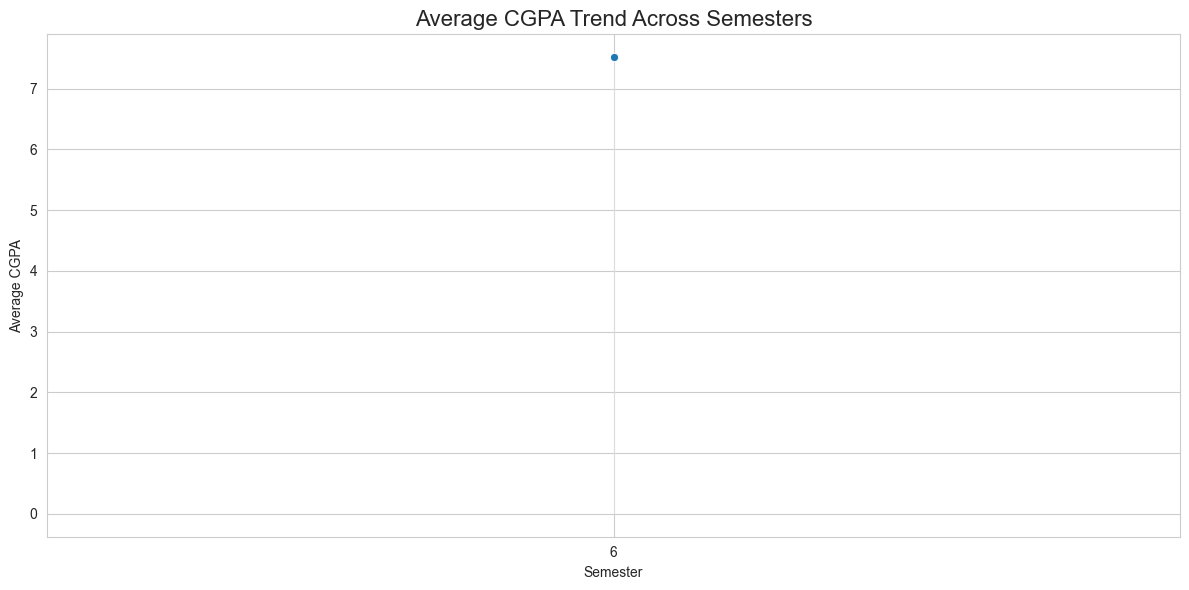

In [6]:
plt.figure()

sns.lineplot(
    data=semester_data,
    x='semester',
    y='cgpa',
    marker='o'
)

plt.fill_between(
    semester_data['semester'],
    semester_data['cgpa'],
    alpha=0.3
)

plt.title("Average CGPA Trend Across Semesters", fontsize=16)
plt.xlabel("Semester")
plt.ylabel("Average CGPA")
plt.xticks(semester_data['semester'])
plt.tight_layout()

plt.show()


TIME-SERIES 2 — Percentage Trend

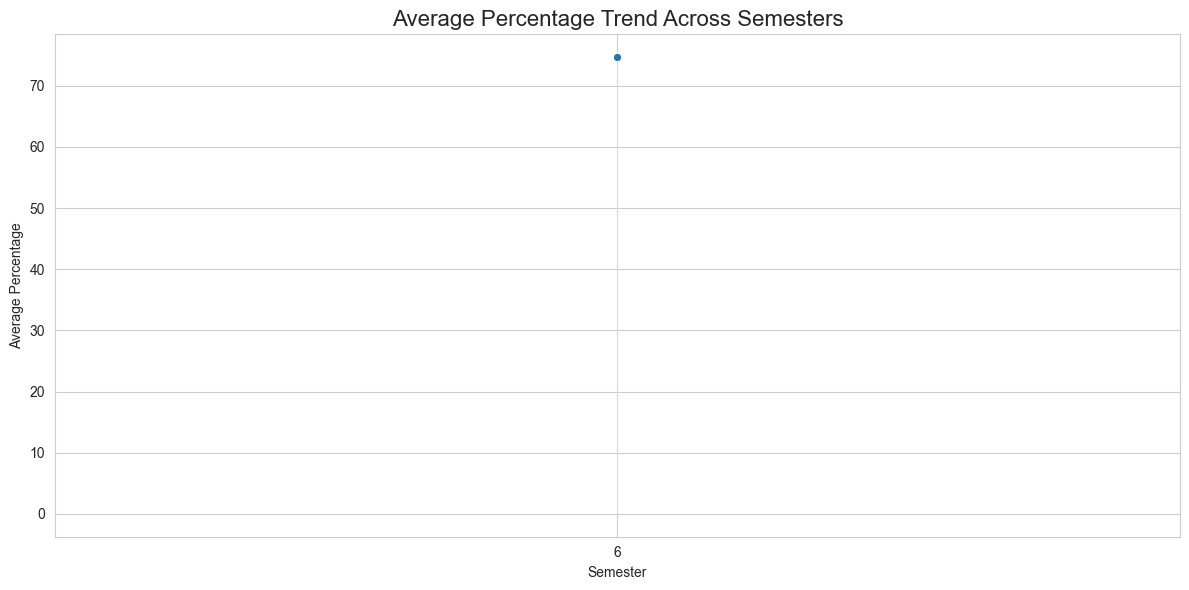

In [7]:
plt.figure()

sns.lineplot(
    data=semester_data,
    x='semester',
    y='percentage',
    marker='o'
)

plt.fill_between(
    semester_data['semester'],
    semester_data['percentage'],
    alpha=0.3
)

plt.title("Average Percentage Trend Across Semesters", fontsize=16)
plt.xlabel("Semester")
plt.ylabel("Average Percentage")
plt.xticks(semester_data['semester'])
plt.tight_layout()

plt.show()


TIME-SERIES 3 — Attendance Trend

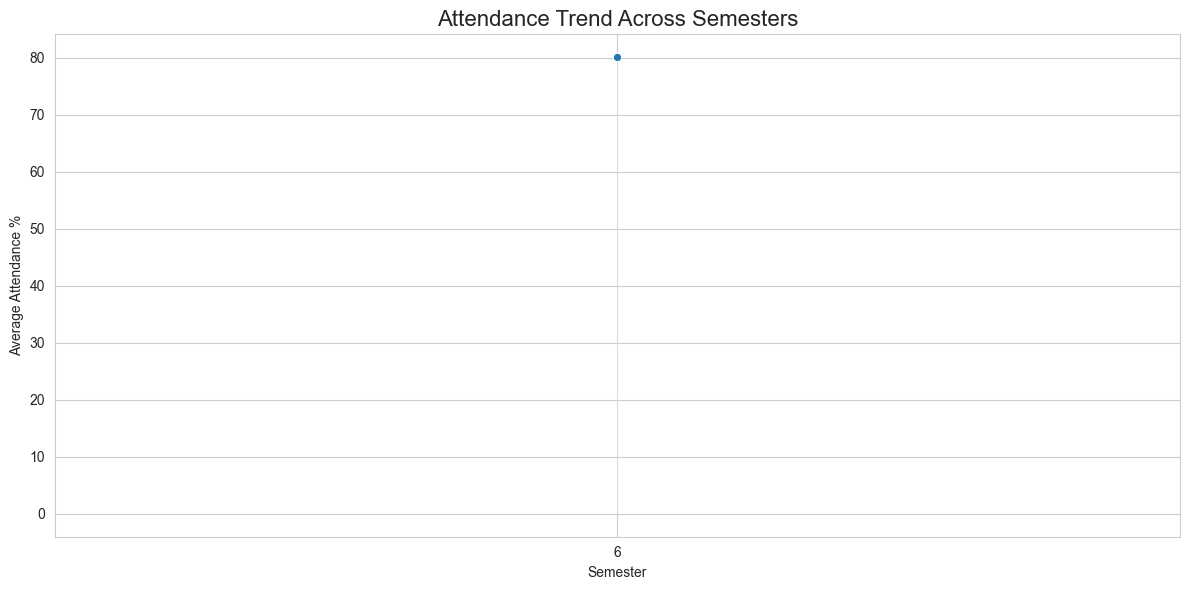

In [8]:
plt.figure()

sns.lineplot(
    data=semester_data,
    x='semester',
    y='attendance_percentage',
    marker='o'
)

plt.fill_between(
    semester_data['semester'],
    semester_data['attendance_percentage'],
    alpha=0.3
)

plt.title("Attendance Trend Across Semesters", fontsize=16)
plt.xlabel("Semester")
plt.ylabel("Average Attendance %")
plt.xticks(semester_data['semester'])
plt.tight_layout()

plt.show()


TIME-SERIES 4 — Stress Level vs CGPA

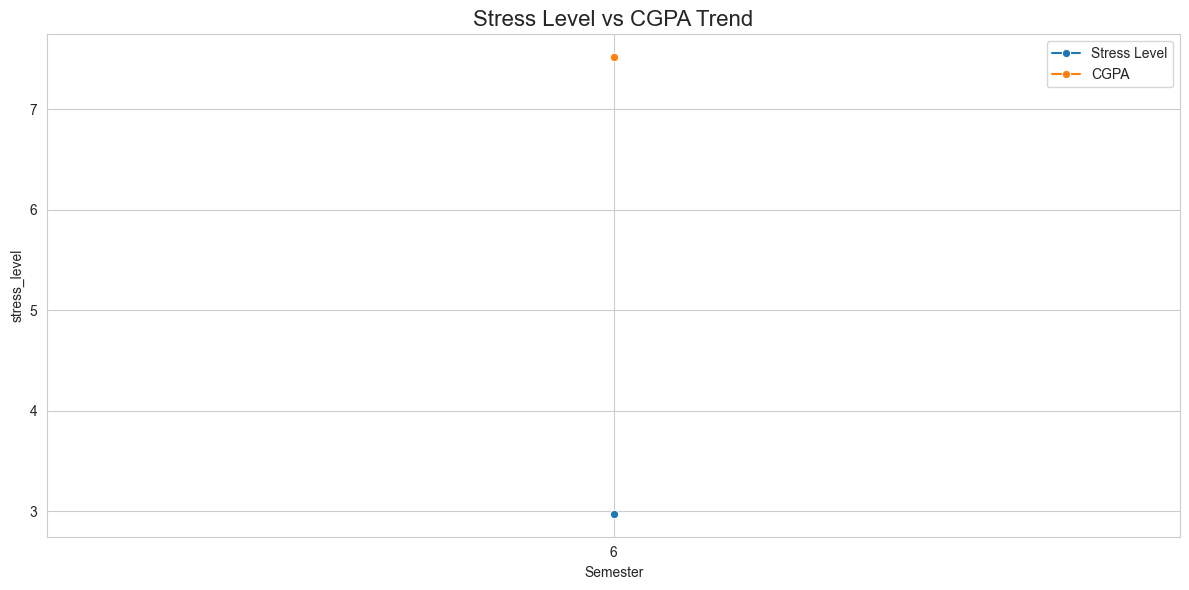

In [9]:
plt.figure()

sns.lineplot(
    data=semester_data,
    x='semester',
    y='stress_level',
    marker='o',
    label='Stress Level'
)

sns.lineplot(
    data=semester_data,
    x='semester',
    y='cgpa',
    marker='o',
    label='CGPA'
)

plt.title("Stress Level vs CGPA Trend", fontsize=16)
plt.xlabel("Semester")
plt.xticks(semester_data['semester'])
plt.legend()
plt.tight_layout()

plt.show()


Placement Training Participation Trend

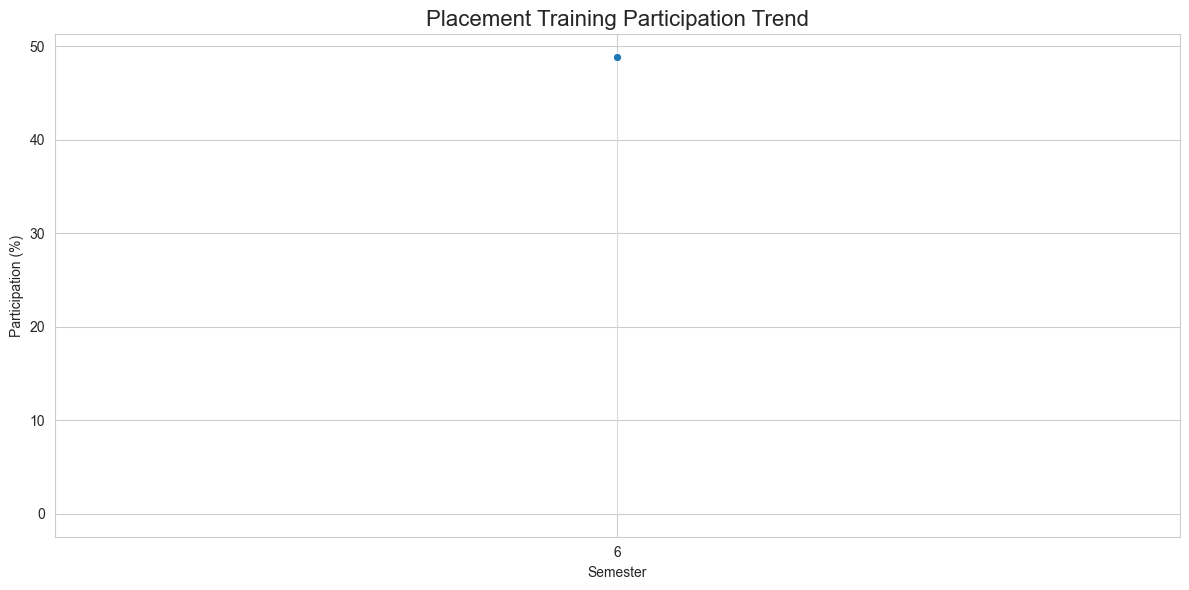

In [10]:
placement_trend = df.groupby('semester')['placement_training_participation'].apply(
    lambda x: (x == "Yes").mean() * 100
).reset_index(name='placement_participation_%')

plt.figure()

sns.lineplot(
    data=placement_trend,
    x='semester',
    y='placement_participation_%',
    marker='o'
)

plt.fill_between(
    placement_trend['semester'],
    placement_trend['placement_participation_%'],
    alpha=0.3
)

plt.title("Placement Training Participation Trend", fontsize=16)
plt.xlabel("Semester")
plt.ylabel("Participation (%)")
plt.xticks(placement_trend['semester'])
plt.tight_layout()

plt.show()
